<a href="https://colab.research.google.com/github/gaurav685/GauravMalhotra/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# 2. Load Dataset

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Liver%20Data.csv"

df = pd.read_csv(url)

# Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

   Age of the patient Gender of the patient  Total Bilirubin  \
0                65.0                Female              0.7   
1                62.0                  Male             10.9   
2                62.0                  Male              7.3   
3                58.0                  Male              1.0   
4                72.0                  Male              3.9   

   Direct Bilirubin   Alkphos Alkaline Phosphotase  \
0               0.1                          187.0   
1               5.5                          699.0   
2               4.1                          490.0   
3               0.4                          182.0   
4               2.0                          195.0   

    Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                            16.0                             18.0   
1                            64.0                            100.0   
2                            60.0                             68.0   
3         

In [ ]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print(df.columns)

# Statistical summary
print(df.describe())

# Data types
print(df.dtypes)

# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Shape: (30691, 11)
Index(['Age of the patient', 'Gender of the patient', 'Total Bilirubin',
       'Direct Bilirubin', ' Alkphos Alkaline Phosphotase',
       ' Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase',
       'Total Protiens', ' ALB Albumin',
       'A/G Ratio Albumin and Globulin Ratio', 'Result'],
      dtype='object')
       Age of the patient  Total Bilirubin  Direct Bilirubin  \
count        30689.000000     30043.000000      30130.000000   
mean            44.107205         3.370319          1.528042   
std             15.981043         6.255522          2.869592   
min              4.000000         0.400000          0.100000   
25%             32.000000         0.800000          0.200000   
50%             45.000000         1.000000          0.300000   
75%             55.000000         2.700000          1.300000   
max             90.000000        75.000000         19.700000   

        Alkphos Alkaline Phosphotase   Sgpt Alamine Aminotransferase  \
co

In [ ]:
# Check missing values
print(df.isnull().sum())

# Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after handling:")
print(df.isnull().sum())

Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64
Missing values after handling:
Age of the patient                      0
Gender of the patient                   0
Total Bilirubin                         0
Direct Bilirubin                        0
 Alkphos Alkaline Phosphotase           0
 Sgpt Alamine Aminotransferase          0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
 ALB Albumin                            0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int

/tmp/ipykernel_651/3554737820.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_651/3554737820.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display cleaned dataset
print(df.head())

   Age of the patient Gender of the patient  Total Bilirubin  \
0                65.0                Female              0.7   
1                62.0                  Male             10.9   
2                62.0                  Male              7.3   
3                58.0                  Male              1.0   
4                72.0                  Male              3.9   

   Direct Bilirubin  Alkphos Alkaline Phosphotase  \
0               0.1                         187.0   
1               5.5                         699.0   
2               4.1                         490.0   
3               0.4                         182.0   
4               2.0                         195.0   

   Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                           16.0                             18.0   
1                           64.0                            100.0   
2                           60.0                             68.0   
3                   

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

df.columns = df.columns.str.replace('\xa0', '', regex=False).str.strip()

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

   Age of the patient  Gender of the patient  Total Bilirubin  \
0            1.285597              -1.562325        -0.422322   
1            1.103546               0.640072         1.262570   
2            1.103546               0.640072         0.667902   
3            0.860812               0.640072        -0.372766   
4            1.710382               0.640072         0.106272   

   Direct Bilirubin  Alkphos Alkaline Phosphotase  \
0         -0.488816                     -0.422255   
1          1.414270                      1.745688   
2          0.920877                      0.860727   
3         -0.383089                     -0.443426   
4          0.180788                     -0.388381   

   Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                      -0.354036                        -0.331773   
1                      -0.086618                        -0.033902   
2                      -0.108903                        -0.150144   
3             

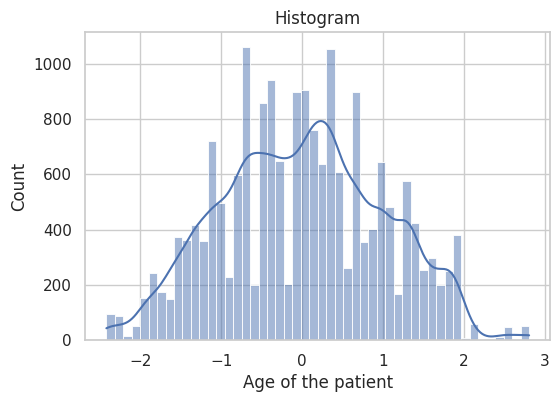

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df[numeric_cols[0]], kde=True)
plt.title("Histogram")
plt.show()

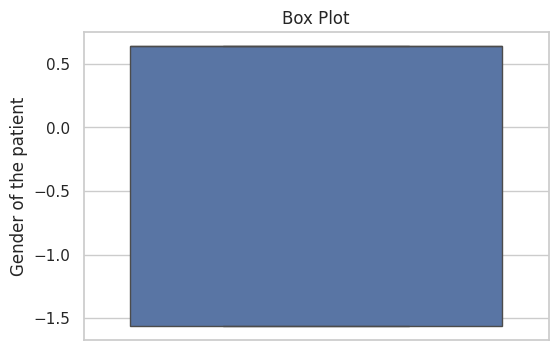

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df[numeric_cols[1]])
plt.title("Box Plot")
plt.show()

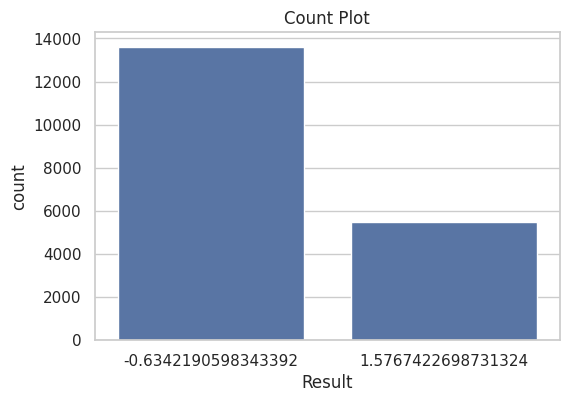

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df[df.columns[-1]])
plt.title("Count Plot")
plt.show()

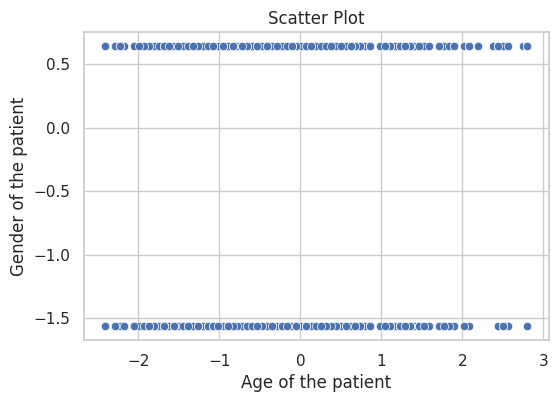

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df[numeric_cols[0]], y=df[numeric_cols[1]])
plt.title("Scatter Plot")
plt.show()

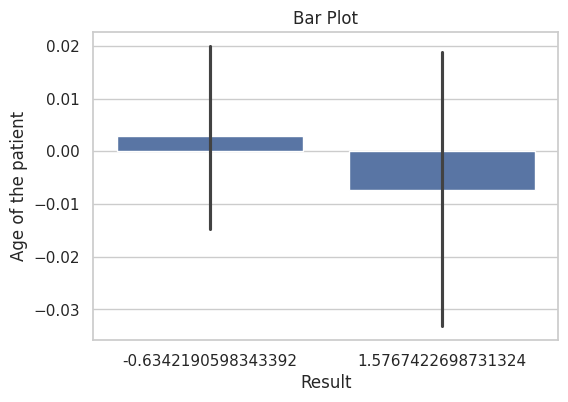

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=df[df.columns[-1]], y=df[numeric_cols[0]])
plt.title("Bar Plot")
plt.show()

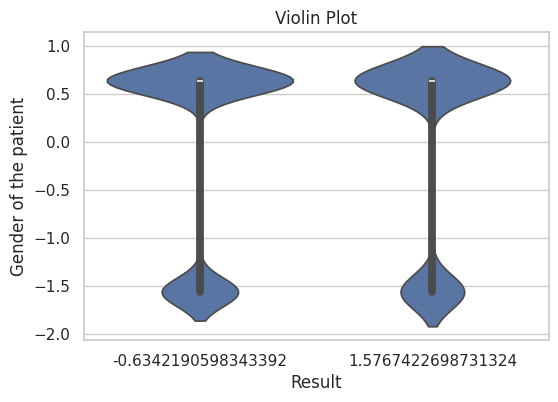

In [ ]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df[df.columns[-1]], y=df[numeric_cols[1]])
plt.title("Violin Plot")
plt.show()

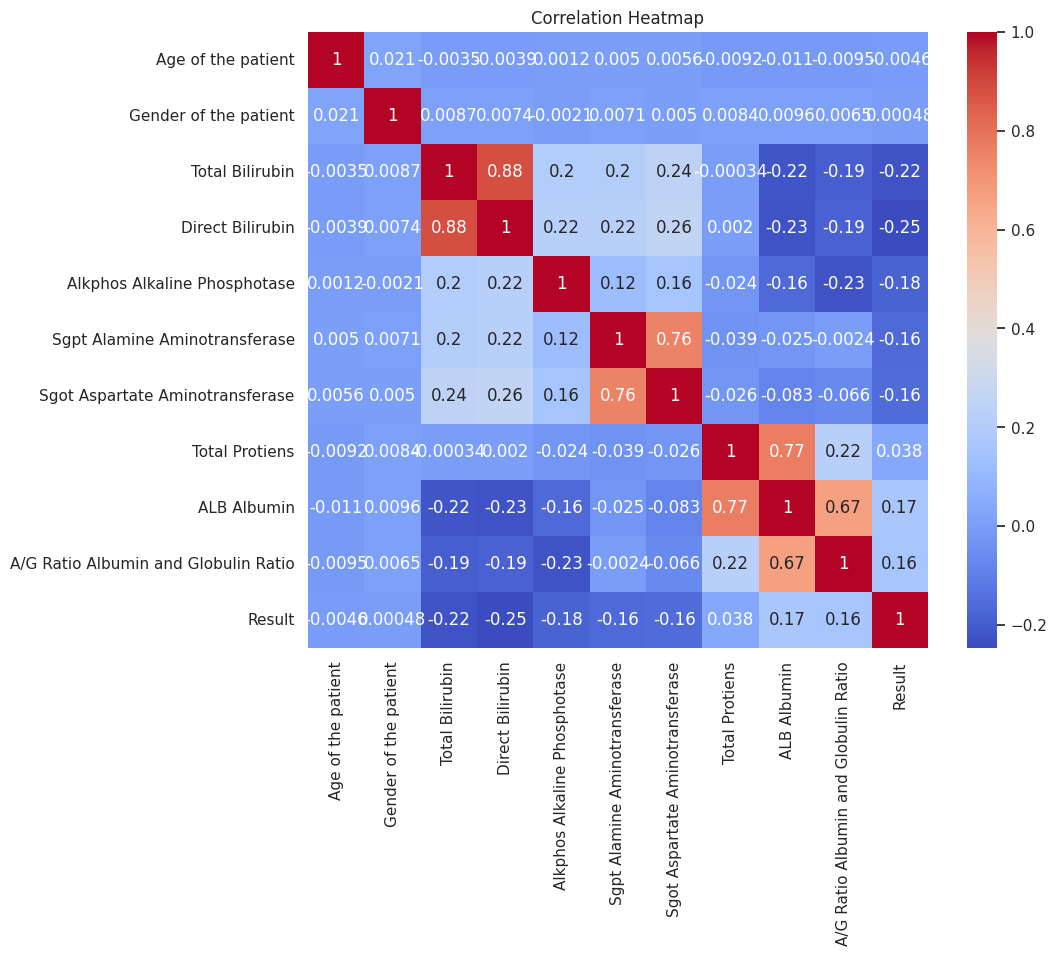

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

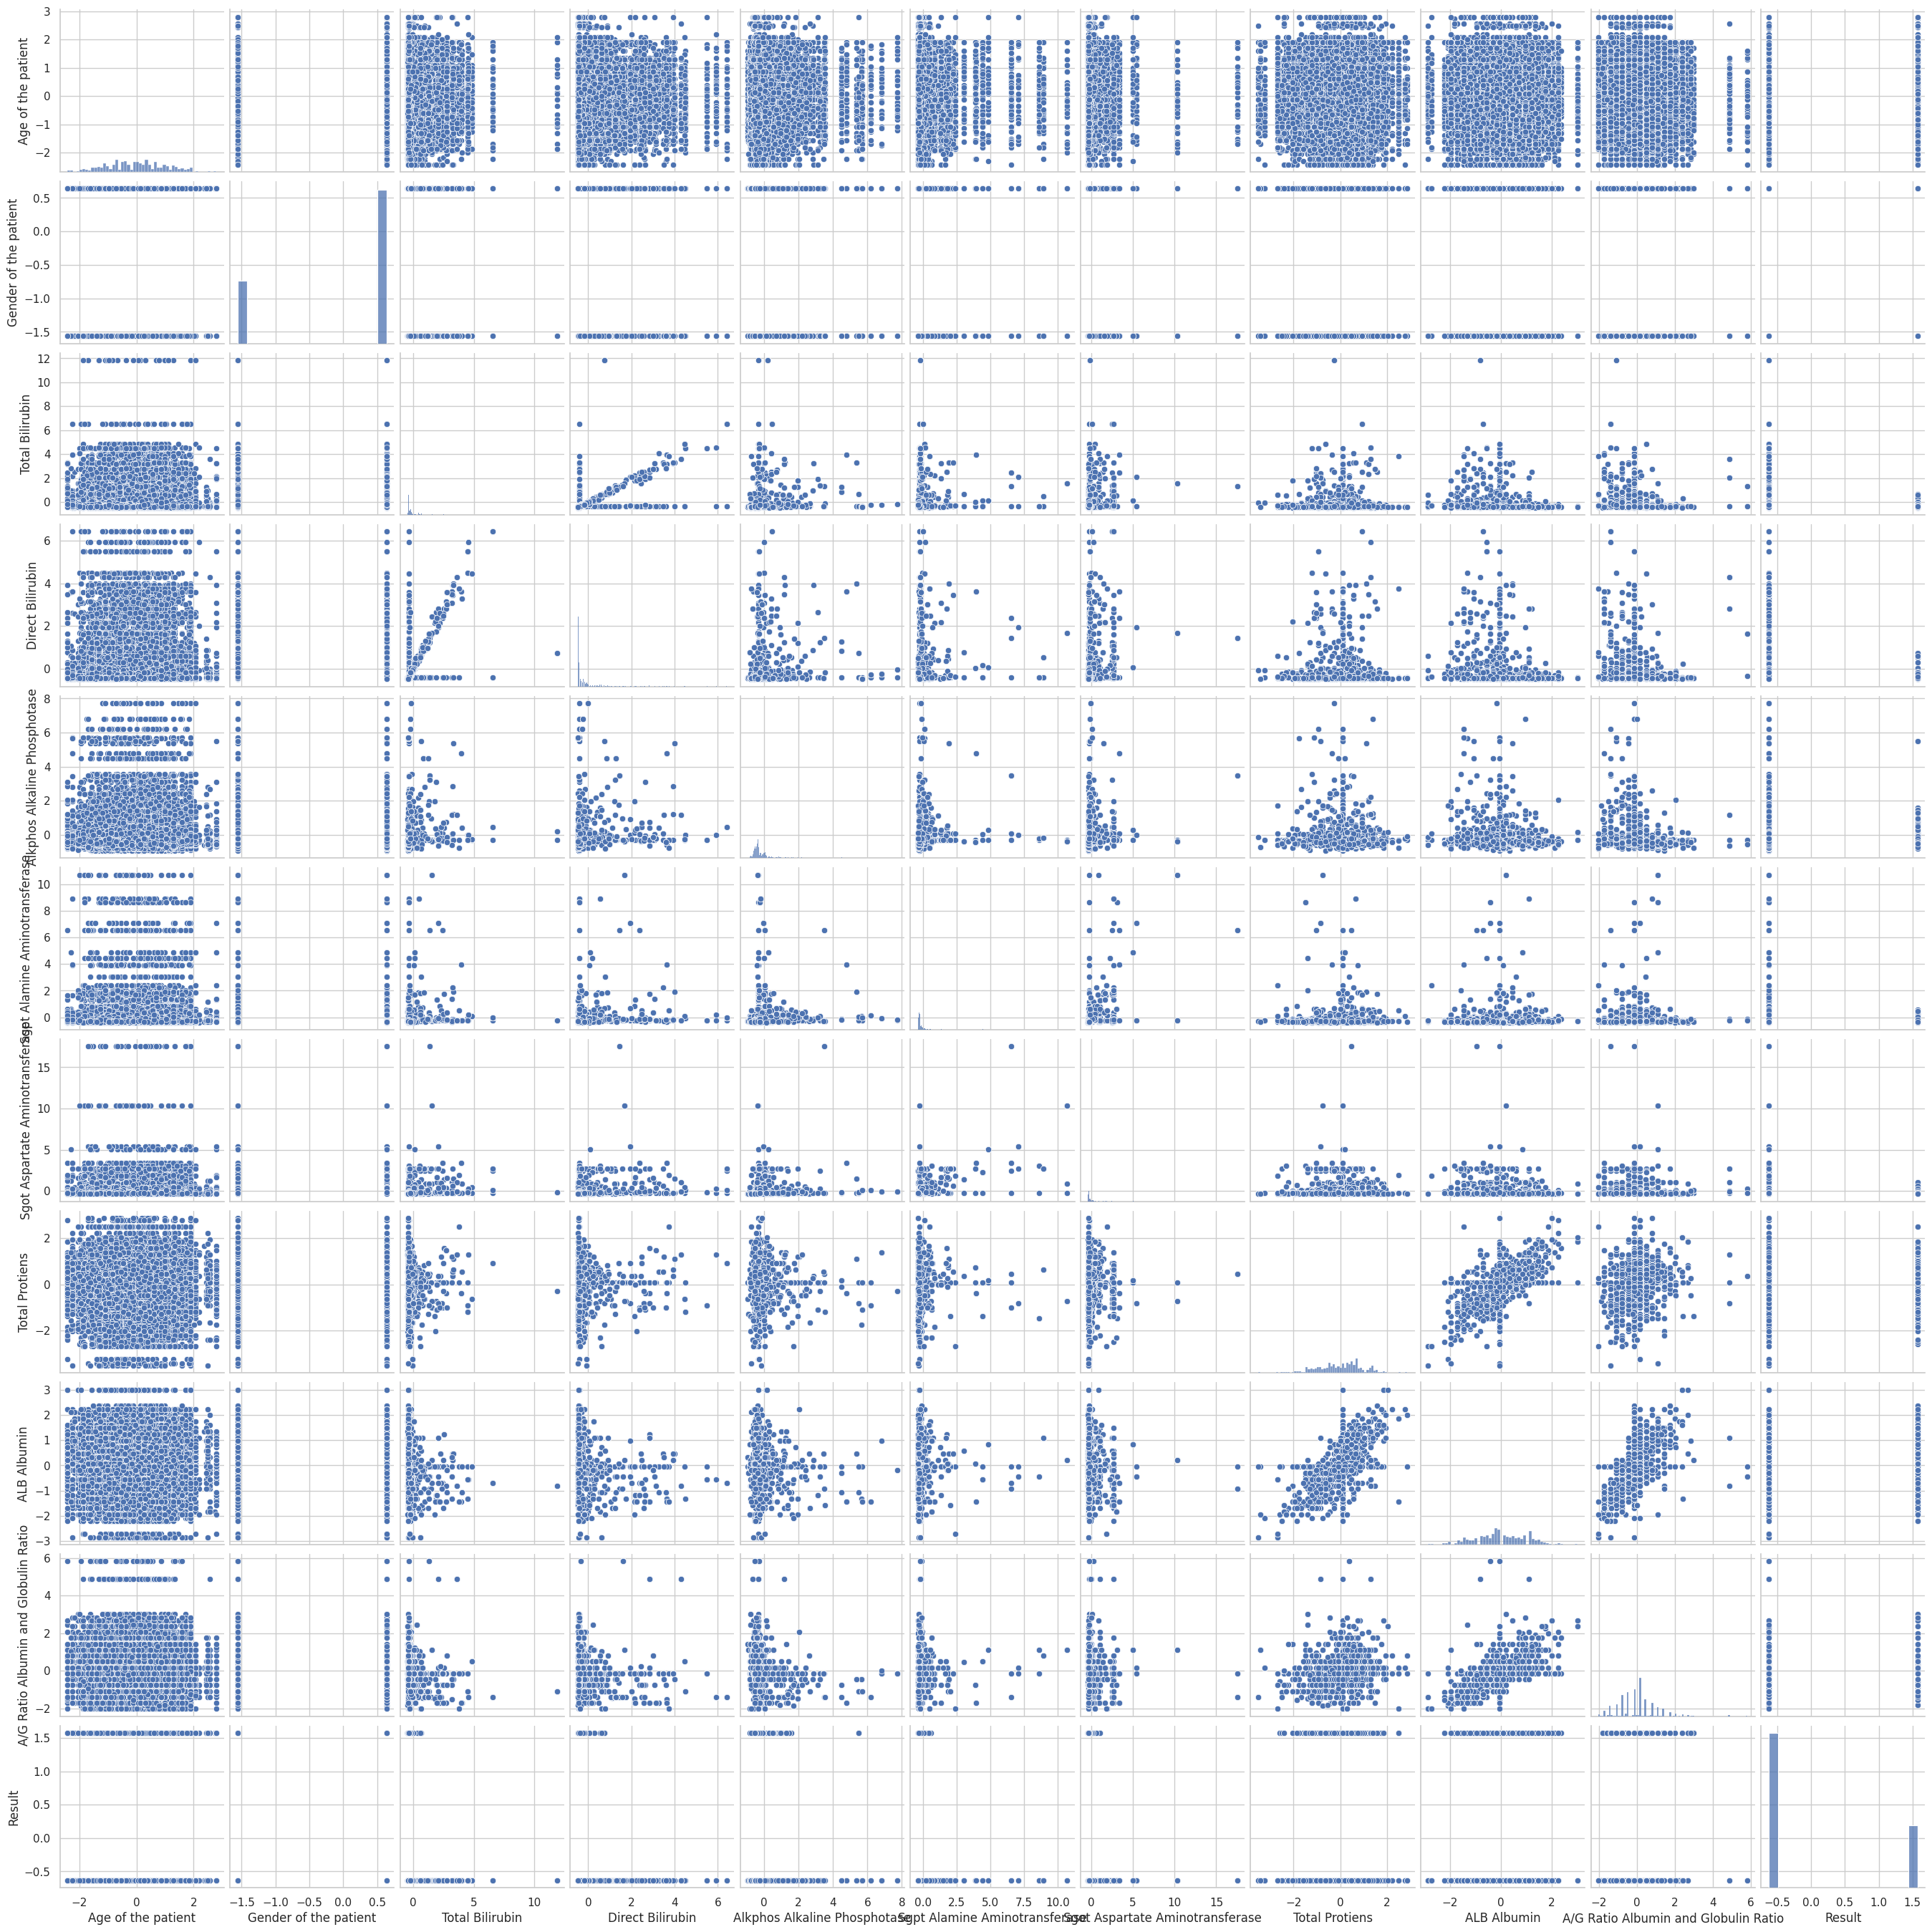

In [ ]:
sns.pairplot(df)
plt.show()

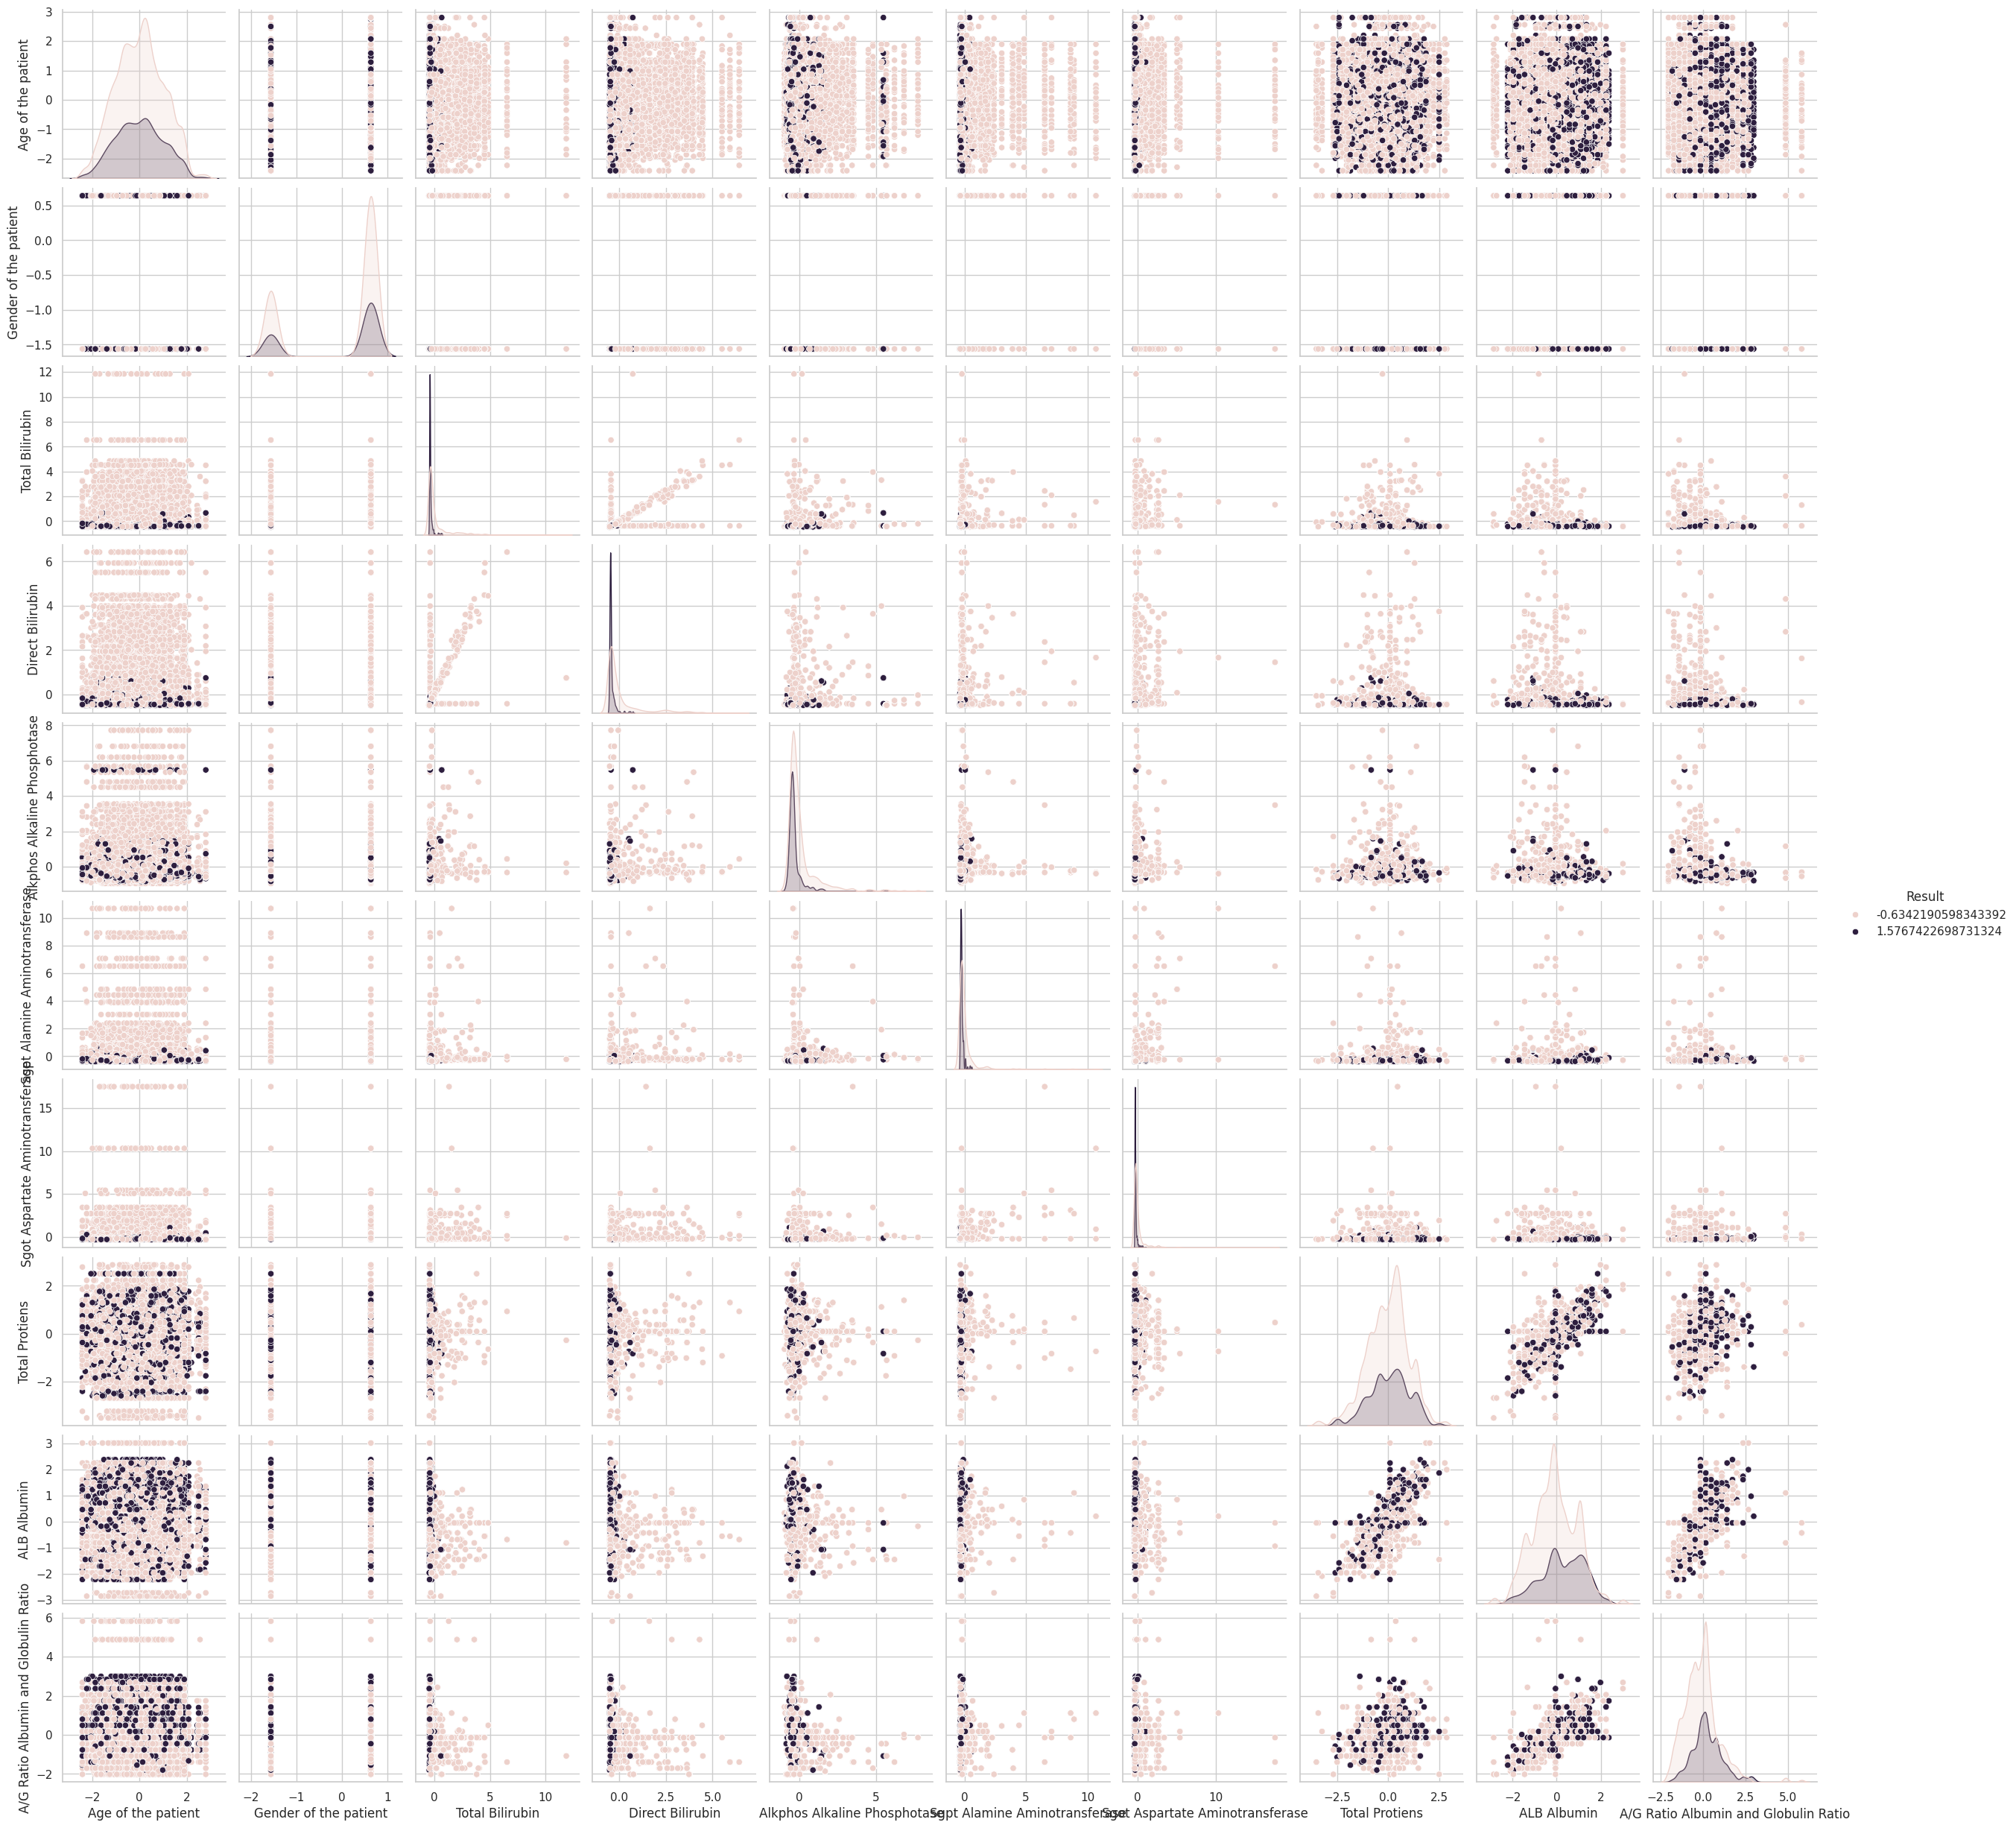

In [ ]:
sns.pairplot(df, hue=df.columns[-1])
plt.show()

In [ ]:
print(df.head())
print(df.describe())

   Age of the patient  Gender of the patient  Total Bilirubin  \
0            1.285597              -1.562325        -0.422322   
1            1.103546               0.640072         1.262570   
2            1.103546               0.640072         0.667902   
3            0.860812               0.640072        -0.372766   
4            1.710382               0.640072         0.106272   

   Direct Bilirubin  Alkphos Alkaline Phosphotase  \
0         -0.488816                     -0.422255   
1          1.414270                      1.745688   
2          0.920877                      0.860727   
3         -0.383089                     -0.443426   
4          0.180788                     -0.388381   

   Sgpt Alamine Aminotransferase  Sgot Aspartate Aminotransferase  \
0                      -0.354036                        -0.331773   
1                      -0.086618                        -0.033902   
2                      -0.108903                        -0.150144   
3             

In [1]:
# Exploratory Data Analysis (EDA) - Liver Patient Dataset
# Name: Gaurav Malhotra
# Registration Number: 23BDS0232
# Institution: Vellore Institute of Technology
# Dataset: Indian Liver Patient Dataset


# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


# 1. Loading the dataset

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Liver%20Data.csv"
df = pd.read_csv(url)

print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

First 5 rows:


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1



Dataset shape: (30691, 11)


In [2]:
# 2. Basic information about the dataset

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

print("\nColumn names:")
print(df.columns.tolist())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8    ALB Albumin                          30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64 

,Age of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
count,30689.000000,30043.000000,30130.000000,29895.000000,30153.000000,30229.000000,30228.000000,30197.000000,30132.000000,30691.000000
mean,44.107205,3.370319,1.528042,289.075364,81.488641,111.469979,6.480237,3.130142,0.943467,1.285882
std,15.981043,6.255522,2.869592,238.537589,182.158850,280.851078,1.081980,0.792281,0.323164,0.451841
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,32.000000,0.800000,0.200000,175.000000,23.000000,26.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,209.000000,35.000000,42.000000,6.600000,3.100000,0.900000,1.000000
75%,55.000000,2.700000,1.300000,298.000000,62.000000,88.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000



Column names:
['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


In [3]:
# Checking skewness and kurtosis

num_cols = df.select_dtypes(include=np.number).columns

stats_check = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})

print("\nSkewness and Kurtosis:")
display(stats_check)


Skewness and Kurtosis:


,Skewness,Kurtosis
Age of the patient,0.027818,-0.487711
Total Bilirubin,4.664615,33.427452
Direct Bilirubin,3.156765,10.878303
Alkphos Alkaline Phosphotase,3.777566,17.991301
Sgpt Alamine Aminotransferase,6.456477,49.196408
Sgot Aspartate Aminotransferase,10.344620,149.362873
Total Protiens,-0.290544,0.205724
ALB Albumin,-0.038985,-0.390472
A/G Ratio Albumin and Globulin Ratio,1.057626,3.543787
Result,0.947821,-1.101707


In [4]:
# 3. Checking missing values

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nMissing value percentage:")
missing_pct = (df.isnull().sum() / len(df)) * 100
display(missing_pct[missing_pct > 0])


Missing values in each column:
Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
 Alkphos Alkaline Phosphotase           796
 Sgpt Alamine Aminotransferase          538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
 ALB Albumin                            494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64

Missing value percentage:


,0
Age of the patient,0.006517
Gender of the patient,2.938972
Total Bilirubin,2.111368
Direct Bilirubin,1.827897
Alkphos Alkaline Phosphotase,2.593594
Sgpt Alamine Aminotransferase,1.752957
Sgot Aspartate Aminotransferase,1.505327
Total Protiens,1.508586
ALB Albumin,1.609592
A/G Ratio Albumin and Globulin Ratio,1.821381


In [5]:
# 4. Data cleaning

# Removing extra spaces from column names
df.columns = df.columns.str.strip()

# Cleaning the gender column
gender_col = 'Gender of the patient'

df[gender_col] = df[gender_col].astype('object')

# Filling missing gender values using the most common gender
if df[gender_col].isnull().sum() > 0:
    df[gender_col] = df[gender_col].fillna(df[gender_col].mode()[0])

# Filling numerical missing values using median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Age of the patient                      0
Gender of the patient                   0
Total Bilirubin                         0
Direct Bilirubin                        0
Alkphos Alkaline Phosphotase            0
Sgpt Alamine Aminotransferase           0
Sgot Aspartate Aminotransferase         0
Total Protiens                          0
ALB Albumin                             0
A/G Ratio Albumin and Globulin Ratio    0
Result                                  0
dtype: int64


In [6]:
# Checking duplicate rows

duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")

print("\nShape after cleaning:", df.shape)


Number of duplicate rows: 11608
Duplicate rows removed.

Shape after cleaning: (19083, 11)


In [7]:
# 5. Data transformation

# Converting gender into a simple numerical variable
df['Gender_flag'] = df[gender_col].map({
    'Male': 1,
    'Female': 0
})

# Creating a readable diagnosis column
df['Diagnosis'] = df['Result'].map({
    1: 'Liver Patient',
    2: 'Healthy'
})

# Creating a binary target column
df['Liver_Disease'] = df['Result'].map({
    1: 1,
    2: 0
})

# Age groups for comparison
age_bins = [0, 18, 30, 45, 60, 100]
age_labels = ['0-18', '19-30', '31-45', '46-60', '60+']

df['Age_Group'] = pd.cut(
    df['Age of the patient'],
    bins=age_bins,
    labels=age_labels
)

print("\nNew columns created:")
display(df[['Gender of the patient',
            'Gender_flag',
            'Result',
            'Diagnosis',
            'Liver_Disease',
            'Age_Group']].head())


New columns created:


,Gender of the patient,Gender_flag,Result,Diagnosis,Liver_Disease,Age_Group
0,Female,0,1,Liver Patient,1,60+
1,Male,1,1,Liver Patient,1,60+
2,Male,1,1,Liver Patient,1,60+
3,Male,1,1,Liver Patient,1,46-60
4,Male,1,1,Liver Patient,1,60+


In [8]:
# 6. Log transformations

# These features are highly skewed, so log values help with visualization
log_cols = [
    'Total Bilirubin',
    'Direct Bilirubin',
    'Alkphos Alkaline Phosphotase',
    'Sgpt Alamine Aminotransferase',
    'Sgot Aspartate Aminotransferase'
]

for col in log_cols:
    df[col + '_log'] = np.log1p(df[col])

print("\nLog transformed columns created.")


Log transformed columns created.


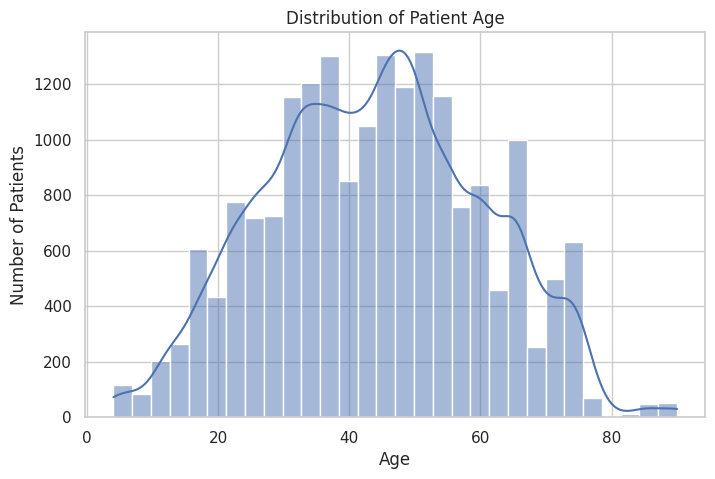

In [9]:
# 7. Univariate analysis

# Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Age of the patient'],
    bins=30,
    kde=True
)

plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

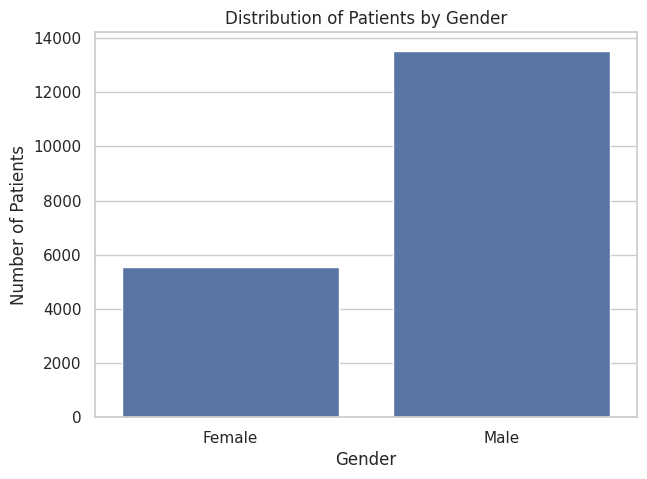

In [10]:
# Gender distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    x=gender_col,
    data=df
)

plt.title('Distribution of Patients by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.show()

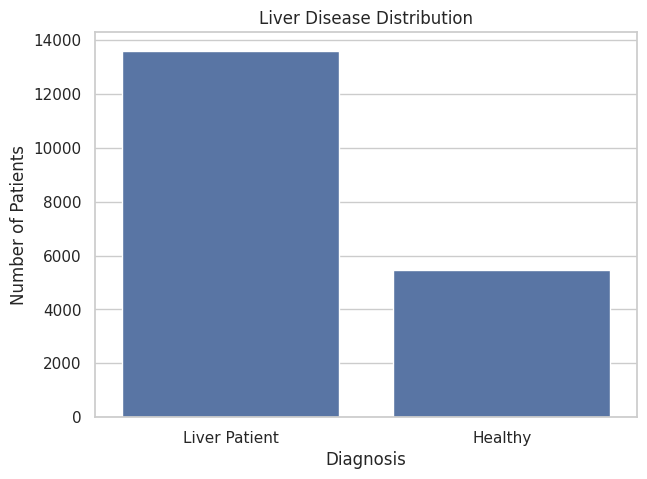

In [11]:
# Diagnosis distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    x='Diagnosis',
    data=df
)

plt.title('Liver Disease Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

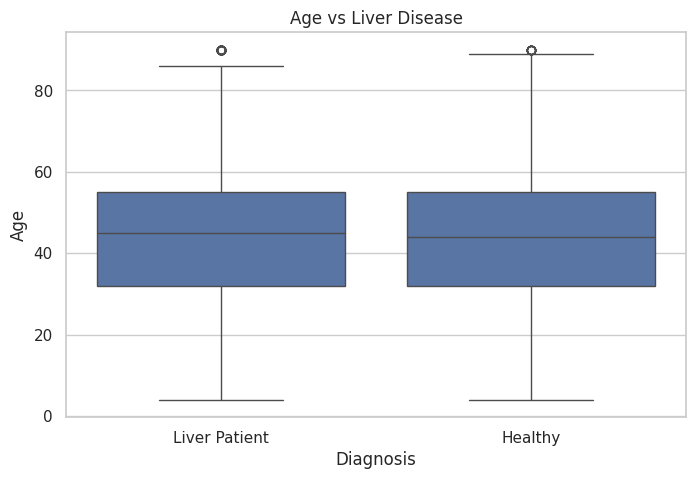

In [12]:
# 8. Bivariate analysis

# Age vs diagnosis

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Diagnosis',
    y='Age of the patient',
    data=df
)

plt.title('Age vs Liver Disease')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.show()

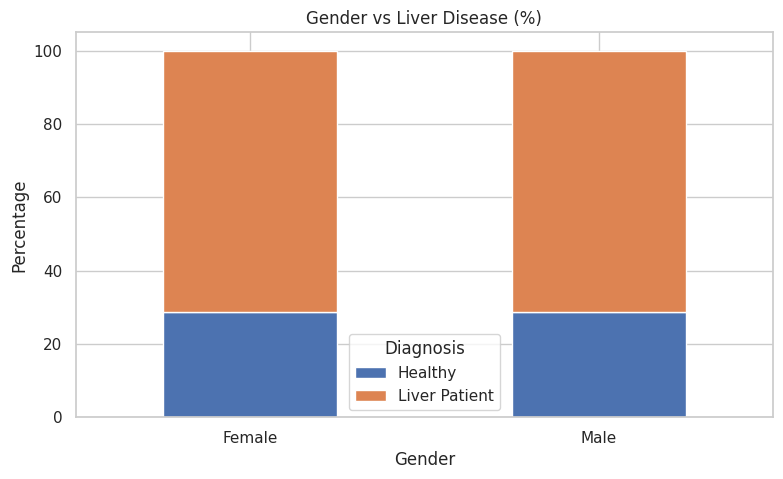

In [13]:
# Gender vs diagnosis

gender_result = pd.crosstab(
    df[gender_col],
    df['Diagnosis'],
    normalize='index'
) * 100

gender_result.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5)
)

plt.title('Gender vs Liver Disease (%)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()

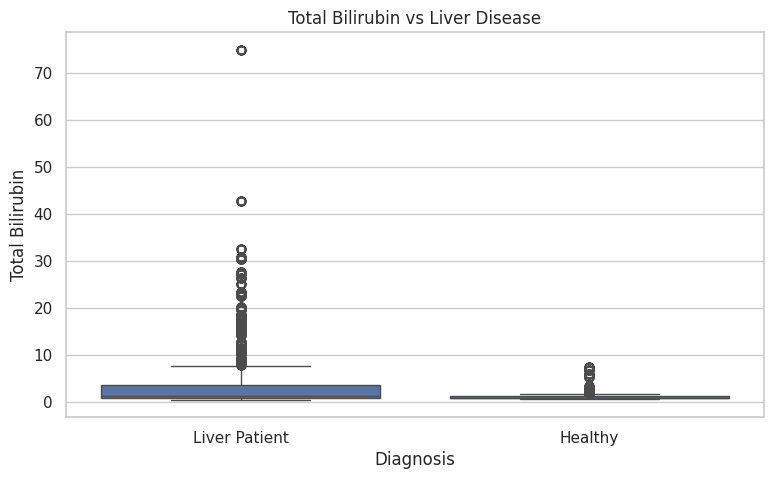

In [14]:
# Bilirubin vs diagnosis

plt.figure(figsize=(9, 5))

sns.boxplot(
    x='Diagnosis',
    y='Total Bilirubin',
    data=df
)

plt.title('Total Bilirubin vs Liver Disease')
plt.xlabel('Diagnosis')
plt.ylabel('Total Bilirubin')
plt.show()

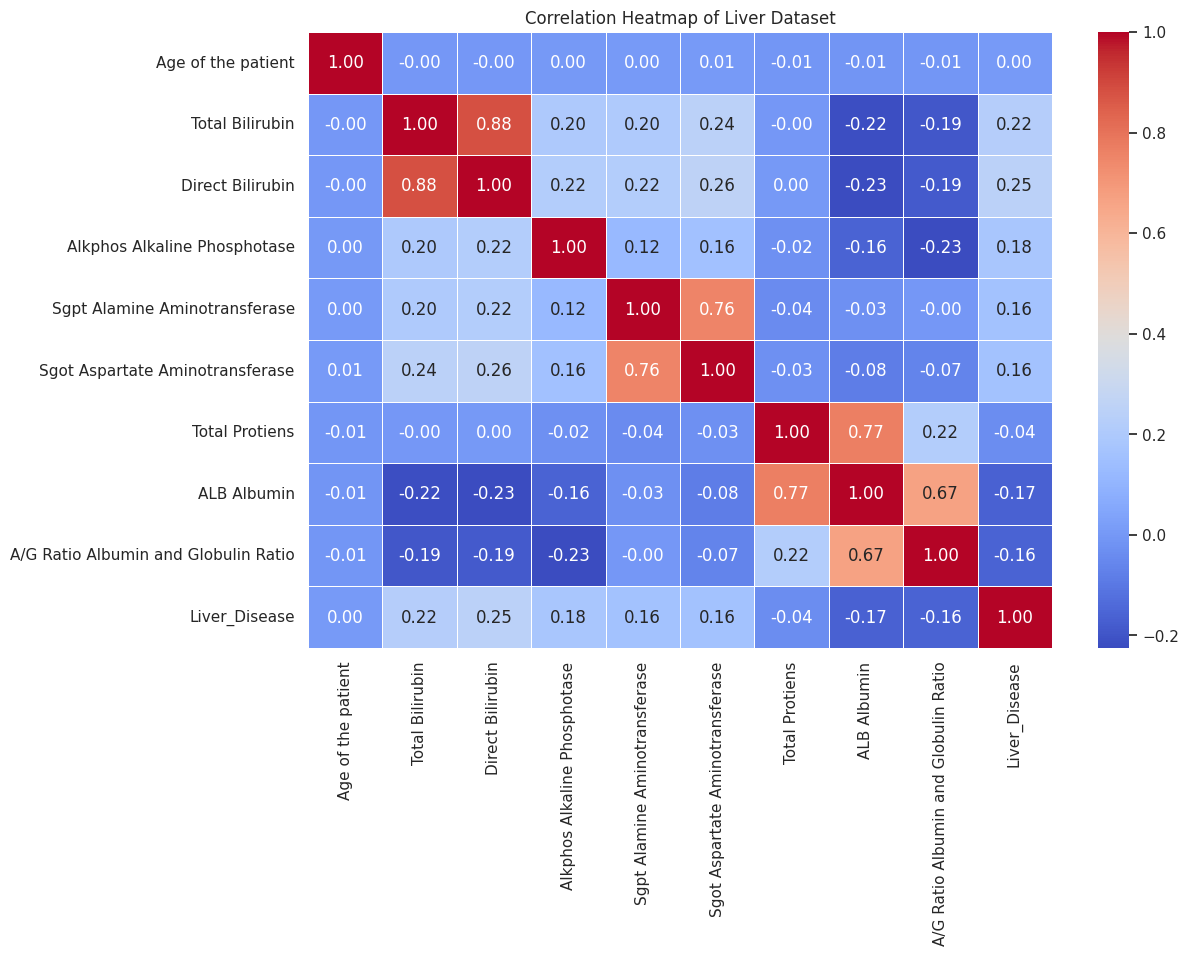

In [15]:
# 9. Multivariate analysis

# Selecting important numerical variables

analysis_cols = [
    'Age of the patient',
    'Total Bilirubin',
    'Direct Bilirubin',
    'Alkphos Alkaline Phosphotase',
    'Sgpt Alamine Aminotransferase',
    'Sgot Aspartate Aminotransferase',
    'Total Protiens',
    'ALB Albumin',
    'A/G Ratio Albumin and Globulin Ratio',
    'Liver_Disease'
]

corr_matrix = df[analysis_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Liver Dataset')
plt.show()

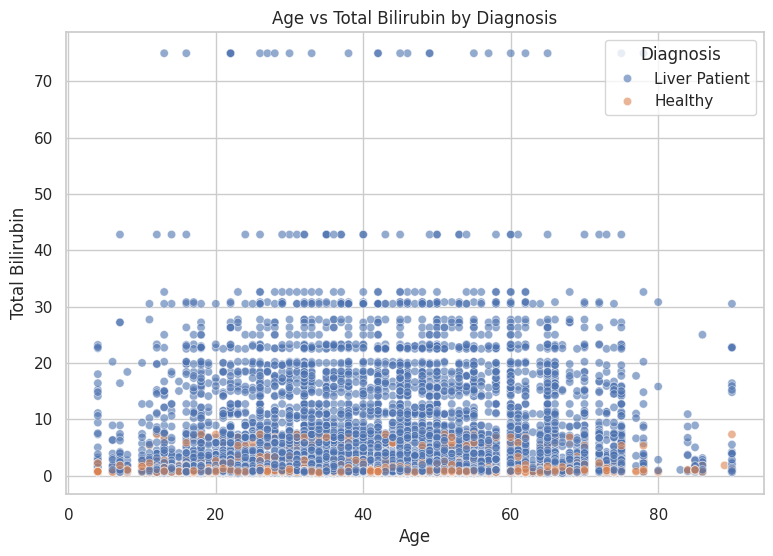

In [16]:
# Age and bilirubin with diagnosis

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x='Age of the patient',
    y='Total Bilirubin',
    hue='Diagnosis',
    data=df,
    alpha=0.6
)

plt.title('Age vs Total Bilirubin by Diagnosis')
plt.xlabel('Age')
plt.ylabel('Total Bilirubin')
plt.show()

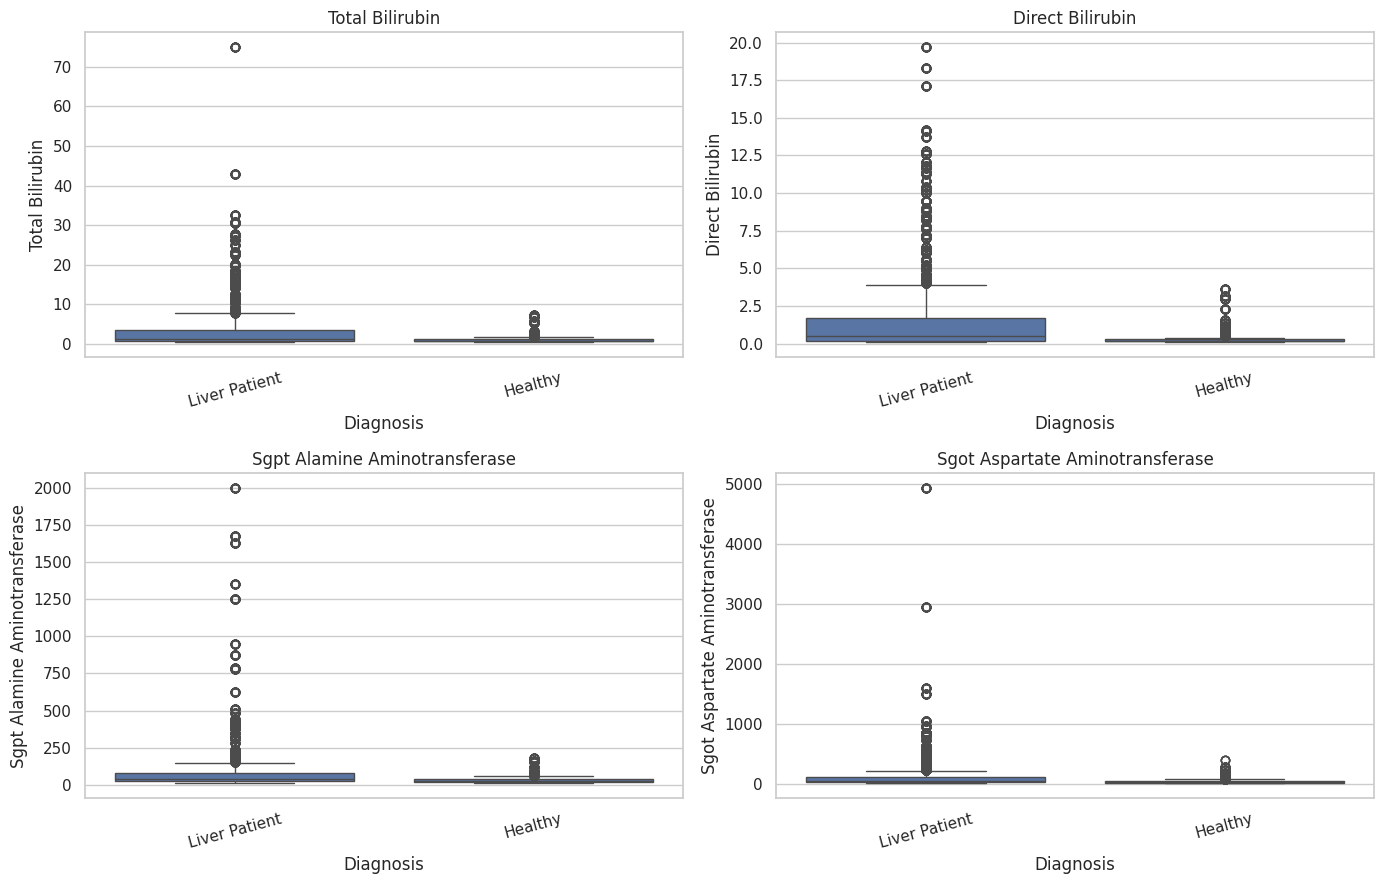

In [17]:
# Multiple liver markers by diagnosis

marker_cols = [
    'Total Bilirubin',
    'Direct Bilirubin',
    'Sgpt Alamine Aminotransferase',
    'Sgot Aspartate Aminotransferase'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), marker_cols):

    sns.boxplot(
        x='Diagnosis',
        y=col,
        data=df,
        ax=ax
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [18]:
# 10. Phase 2 - 1D statistical analysis

print("\n--- 1D Statistical Analysis ---")

one_d_cols = [
    'Age of the patient',
    'Total Bilirubin',
    'Total Protiens',
    'ALB Albumin',
    'A/G Ratio Albumin and Globulin Ratio'
]

display(df[one_d_cols].describe().T)


--- 1D Statistical Analysis ---


,count,mean,std,min,25%,50%,75%,max
Age of the patient,19083.0,43.814757,16.479348,4.0,32.0,45.0,55.0,90.0
Total Bilirubin,19083.0,3.256653,6.053960,0.4,0.8,1.0,2.6,75.0
Total Protiens,19083.0,6.496924,1.078985,2.7,5.8,6.6,7.2,9.6
ALB Albumin,19083.0,3.140151,0.785287,0.9,2.6,3.1,3.8,5.5
A/G Ratio Albumin and Globulin Ratio,19083.0,0.944804,0.318582,0.3,0.7,0.9,1.1,2.8


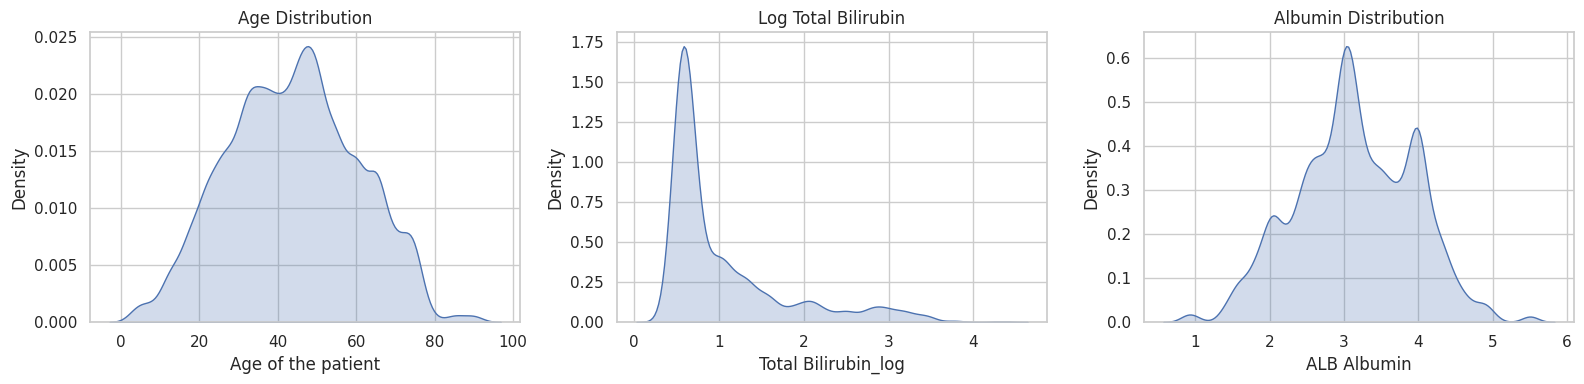

In [19]:
# 1D density plots

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4)
)

sns.kdeplot(
    df['Age of the patient'],
    ax=axes[0],
    fill=True
)

axes[0].set_title('Age Distribution')


sns.kdeplot(
    df['Total Bilirubin_log'],
    ax=axes[1],
    fill=True
)

axes[1].set_title('Log Total Bilirubin')


sns.kdeplot(
    df['ALB Albumin'],
    ax=axes[2],
    fill=True
)

axes[2].set_title('Albumin Distribution')

plt.tight_layout()
plt.show()


--- 2D Statistical Analysis ---


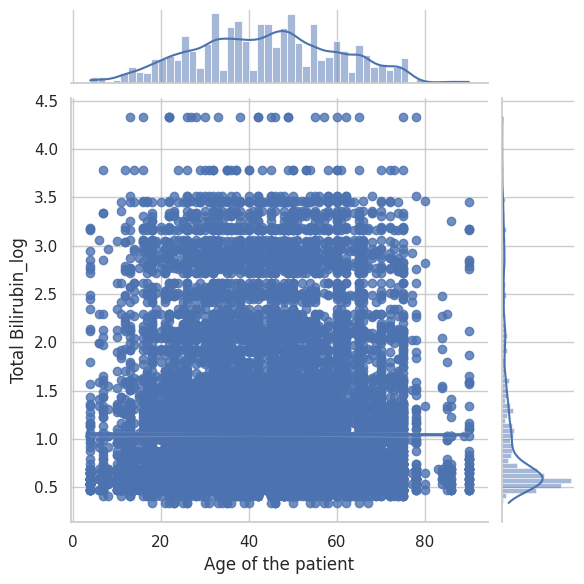

In [20]:
# 11. Phase 2 - 2D statistical analysis

print("\n--- 2D Statistical Analysis ---")

# Age and bilirubin relationship

sns.jointplot(
    x='Age of the patient',
    y='Total Bilirubin_log',
    data=df,
    kind='reg',
    height=6
)

plt.show()

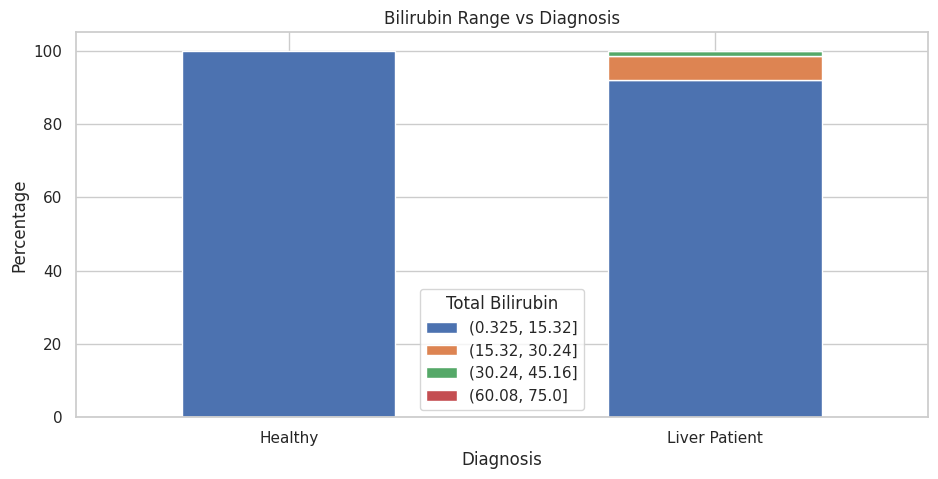

In [21]:
# Bilirubin and diagnosis

result_bilirubin = pd.crosstab(
    df['Diagnosis'],
    pd.cut(
        df['Total Bilirubin'],
        bins=5
    ),
    normalize='index'
) * 100

result_bilirubin.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 5)
)

plt.title('Bilirubin Range vs Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.show()


--- 3D Statistical Analysis ---


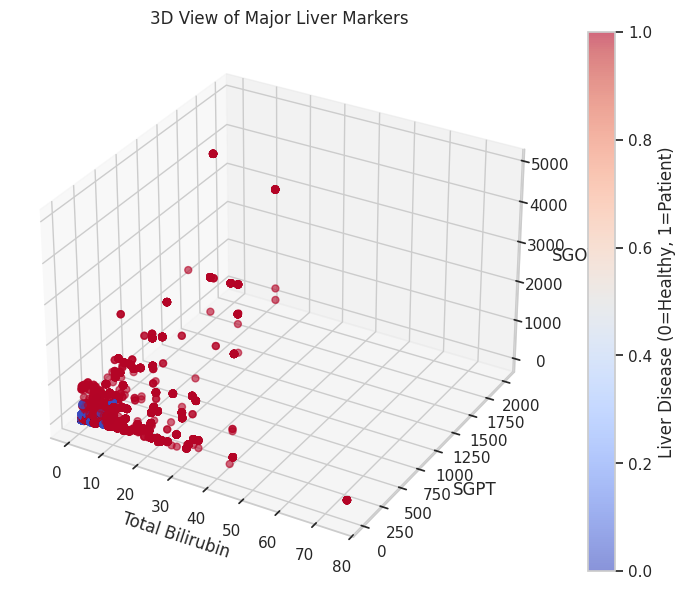

In [22]:
# 12. Phase 2 - 3D statistical analysis

print("\n--- 3D Statistical Analysis ---")

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

plot_3d = ax.scatter(
    df['Total Bilirubin'],
    df['Sgpt Alamine Aminotransferase'],
    df['Sgot Aspartate Aminotransferase'],
    c=df['Liver_Disease'],
    cmap='coolwarm',
    alpha=0.6,
    s=25
)

ax.set_xlabel('Total Bilirubin')
ax.set_ylabel('SGPT')
ax.set_zlabel('SGOT')

plt.title('3D View of Major Liver Markers')

fig.colorbar(
    plot_3d,
    ax=ax,
    label='Liver Disease (0=Healthy, 1=Patient)'
)

plt.show()

In [24]:
# 13. Preparing data for clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [25]:
# Using numerical health indicators for clustering

cluster_features = [
    'Age of the patient',
    'Total Bilirubin',
    'Direct Bilirubin',
    'Alkphos Alkaline Phosphotase',
    'Sgpt Alamine Aminotransferase',
    'Sgot Aspartate Aminotransferase',
    'Total Protiens',
    'ALB Albumin',
    'A/G Ratio Albumin and Globulin Ratio'
]

cluster_data = df[cluster_features].copy()

In [26]:
# Scaling the values before clustering

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_data
)

print("\nData scaled successfully.")


Data scaled successfully.



--- K-Means Clustering ---


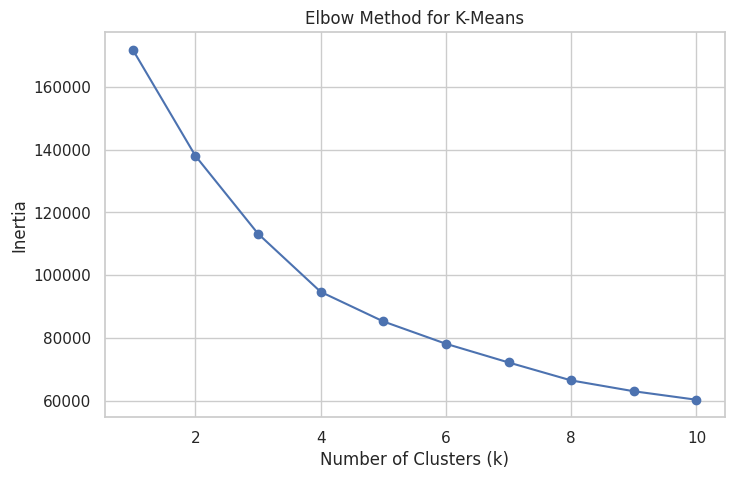

In [27]:
# 14. K-Means clustering

print("\n--- K-Means Clustering ---")

# Checking different values of k using elbow method

inertia_values = []

k_values = range(1, 11)

for k in k_values:

    kmeans_test = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans_test.fit(scaled_data)

    inertia_values.append(
        kmeans_test.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')

plt.show()

In [28]:
# Applying K-Means with 3 clusters

kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(
    scaled_data
)

print("\nK-Means cluster counts:")
print(df['KMeans_Cluster'].value_counts())


K-Means cluster counts:
KMeans_Cluster
1    9416
0    7870
2    1797
Name: count, dtype: int64


In [30]:
# 15. PCA for visualizing K-Means clusters

pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    scaled_data
)

df['PCA_1'] = pca_data[:, 0]
df['PCA_2'] = pca_data[:, 1]

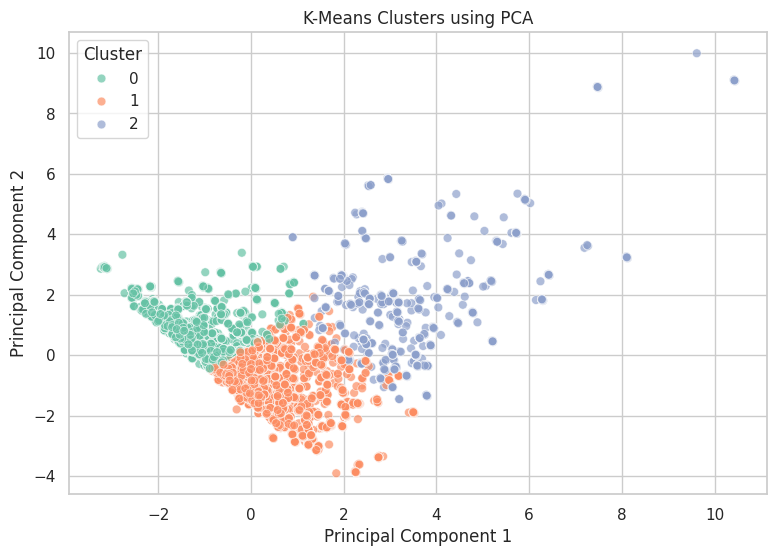

In [31]:
# Visualizing K-Means clusters using PCA

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x='PCA_1',
    y='PCA_2',
    hue='KMeans_Cluster',
    data=df,
    palette='Set2',
    alpha=0.7,
    s=40
)

plt.title('K-Means Clusters using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

In [32]:
# 16. Hierarchical clustering

print("\n--- Hierarchical Clustering ---")

# Using a sample for the dendrogram to keep the plot readable

sample_size = min(150, len(df))

sample_index = df.sample(
    n=sample_size,
    random_state=42
).index

sample_data = scaled_data[
    df.index.get_indexer(sample_index)
]


--- Hierarchical Clustering ---


In [33]:

# Creating the linkage matrix

linkage_data = linkage(
    sample_data,
    method='ward'
)

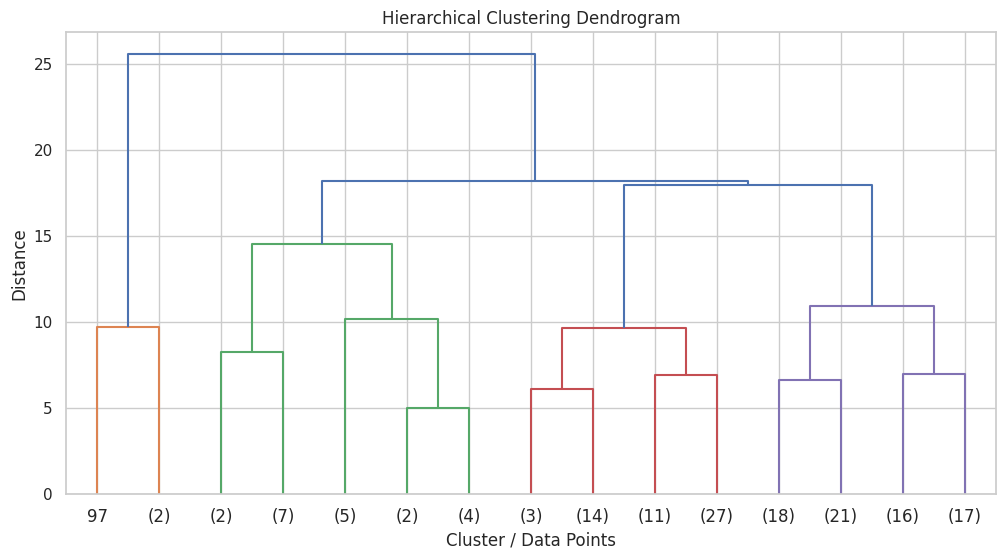

In [35]:
# Dendrogram

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_data,
    truncate_mode='lastp',
    p=15
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster / Data Points')
plt.ylabel('Distance')

plt.show()

In [36]:
# 17. Applying hierarchical clustering

hierarchical_model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

df['Hierarchical_Cluster'] = hierarchical_model.fit_predict(
    scaled_data
)

In [37]:
# Cluster counts

print("\nHierarchical cluster counts:")

print(
    df['Hierarchical_Cluster'].value_counts()
)


Hierarchical cluster counts:
Hierarchical_Cluster
1    11846
2     5765
0     1472
Name: count, dtype: int64


In [38]:
# 18. Comparing both clustering methods

print("\nK-Means cluster distribution:")

print(
    df['KMeans_Cluster'].value_counts()
)

print("\nHierarchical cluster distribution:")

print(
    df['Hierarchical_Cluster'].value_counts()
)


K-Means cluster distribution:
KMeans_Cluster
1    9416
0    7870
2    1797
Name: count, dtype: int64

Hierarchical cluster distribution:
Hierarchical_Cluster
1    11846
2     5765
0     1472
Name: count, dtype: int64


In [39]:
# 19. Looking at cluster characteristics

cluster_summary = df.groupby(
    'KMeans_Cluster'
)[cluster_features].mean()

print("\nAverage values for each K-Means cluster:")

display(cluster_summary)


Average values for each K-Means cluster:


,Age of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio
KMeans_Cluster,,,,,,,,,
0,43.220076,1.326595,0.546557,234.741550,49.294917,59.196823,7.270407,3.876137,1.165180
1,44.230353,2.077581,0.933050,304.742672,54.520603,79.839741,5.848980,2.606765,0.793640
2,44.241514,17.887535,8.508459,419.959933,343.175292,483.444073,6.504563,2.711742,0.771742


In [40]:
# 20. Final dataset check

print("\nFinal dataset shape:", df.shape)

print("\nFinal columns:")

print(df.columns.tolist())

print("\nFirst 5 rows after all transformations:")

display(df.head())


Final dataset shape: (19083, 24)

Final columns:
['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', 'Alkphos Alkaline Phosphotase', 'Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', 'ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result', 'Gender_flag', 'Diagnosis', 'Liver_Disease', 'Age_Group', 'Total Bilirubin_log', 'Direct Bilirubin_log', 'Alkphos Alkaline Phosphotase_log', 'Sgpt Alamine Aminotransferase_log', 'Sgot Aspartate Aminotransferase_log', 'KMeans_Cluster', 'PCA_1', 'PCA_2', 'Hierarchical_Cluster']

First 5 rows after all transformations:


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,...,Age_Group,Total Bilirubin_log,Direct Bilirubin_log,Alkphos Alkaline Phosphotase_log,Sgpt Alamine Aminotransferase_log,Sgot Aspartate Aminotransferase_log,KMeans_Cluster,PCA_1,PCA_2,Hierarchical_Cluster
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,...,60+,0.530628,0.095310,5.236442,2.833213,2.944439,0,-0.818609,-0.315152,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,...,60+,2.476538,1.871802,6.551080,4.174387,4.615121,2,1.556091,0.880382,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,...,60+,2.116256,1.629241,6.196444,4.110874,4.234107,1,0.707195,0.552206,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,...,46-60,0.693147,0.336472,5.209486,2.708050,3.044522,0,-0.919634,-0.103020,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,...,60+,1.589235,1.098612,5.278115,3.332205,4.094345,1,0.693237,-0.860295,1
